In [9]:
import pandas as pd
import plotly.express as px
import numpy as np
import seaborn as sns
from src.options import EuropeanOption
import pstats

## Using data generated from 'generate_cn_data.ipynb'

In [10]:
filename = 'profiled_cn_run'
data = pd.read_parquet(f'./data/{filename}.parquet')
stats = pstats.Stats(f'./data/{filename}.prof')
K, T, S0, r, sigma = data[['K', 'T', 'S0','r', 'sigma']].iloc[0]

In [11]:
stats.strip_dirs()
stats.sort_stats("cumulative")
stats.print_stats('pde_crank_nicolson')

Fri Sep 11 09:51:40 2026    ./data/profiled_cn_run_eu.prof

         335286 function calls (332022 primitive calls) in 21.125 seconds

   Ordered by: cumulative time
   List reduced from 1178 to 2 due to restriction <'pde_crank_nicolson'>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      720   12.733    0.018   12.765    0.018 fdm.py:672(pde_crank_nicolson_v6)
      720    5.850    0.008    5.880    0.008 fdm.py:802(pde_crank_nicolson_v7)




In [12]:
df=data.copy()
df = df.drop(columns=['K', 'T', 'S0', 'r', 'sigma'])
df['normalised_time']= 1e3 * df['time']/df['t_steps']
df = df.sort_values(['method', 't_steps', 's_steps']) # have to sort here, as either pandas or sns has a bug where it stores two different orders of categories/columns, results in incorrect legends.
#df.info()

In [13]:

from src.fdm import build_grid, pde_crank_nicolson, pde_crank_nicolson_v2, pde_crank_nicolson_v3, pde_crank_nicolson_v4, \
    pde_crank_nicolson_v5, pde_crank_nicolson_v6


def get_grid_spacings(row):
    _, dx, _, dt, _ = build_grid(K, S0, r, T, sigma, s_steps=row['s_steps'], t_steps=row['t_steps'], n_std=5)
    return pd.Series([dx,dt])

def get_lambda(row):
    alpha = 0.5*(sigma**2)
    dt = row['dt']
    dx_squared = row['dx']**2
    return alpha * dt / dx_squared

df[['dx', 'dt']] = df.apply(get_grid_spacings, axis=1)
df.count()

s_steps            1440
t_steps            1440
version            1440
method             1440
result             1440
time               1440
started            1440
normalised_time    1440
dx                 1440
dt                 1440
dtype: int64

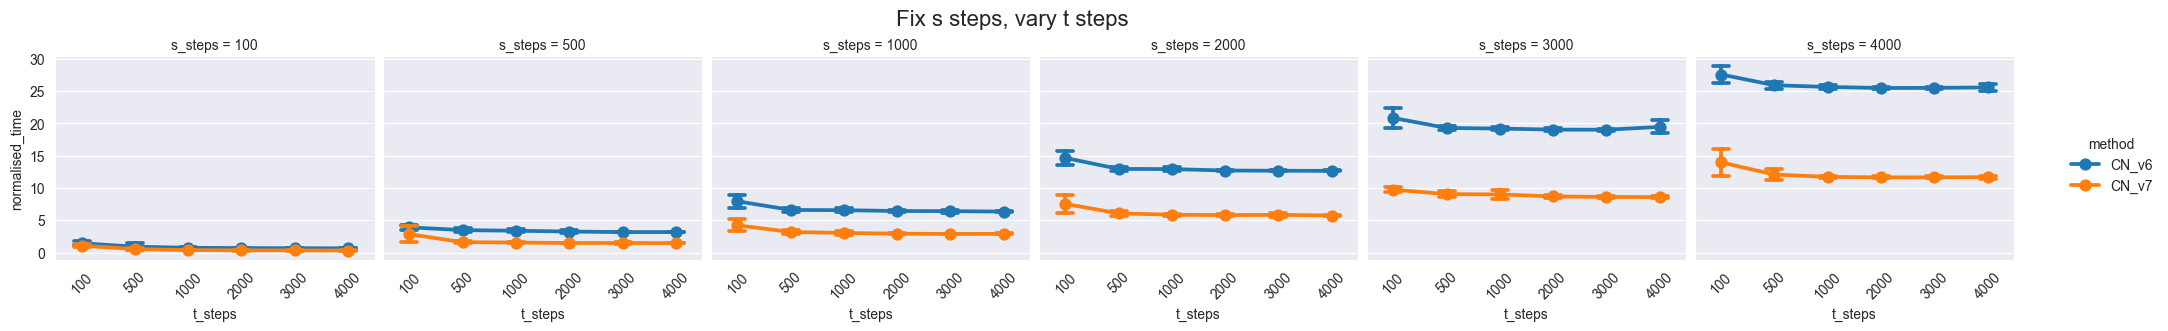

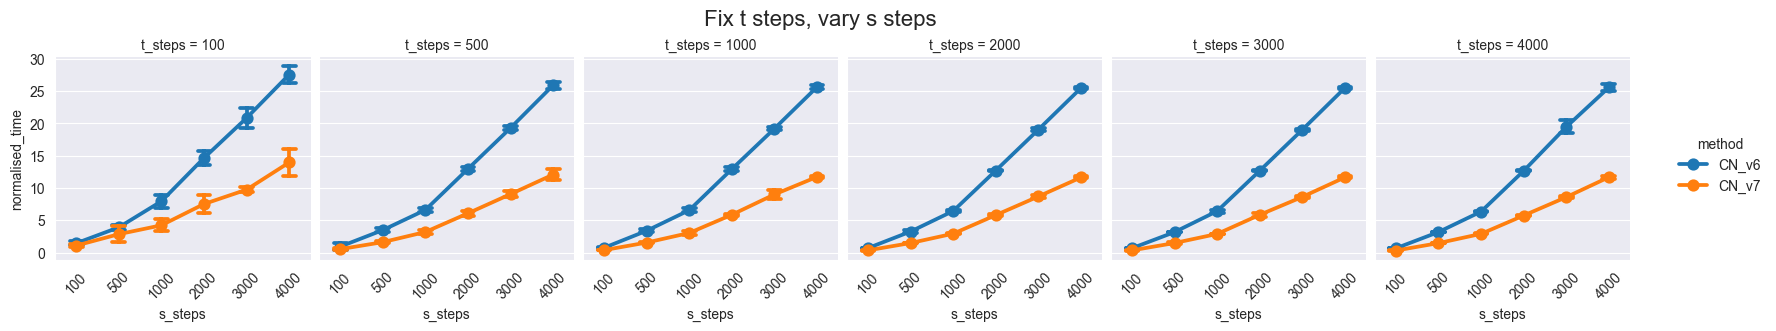

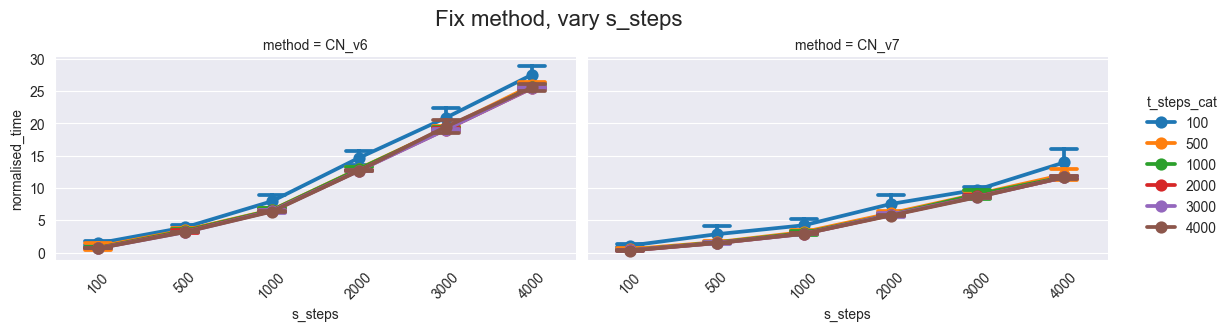

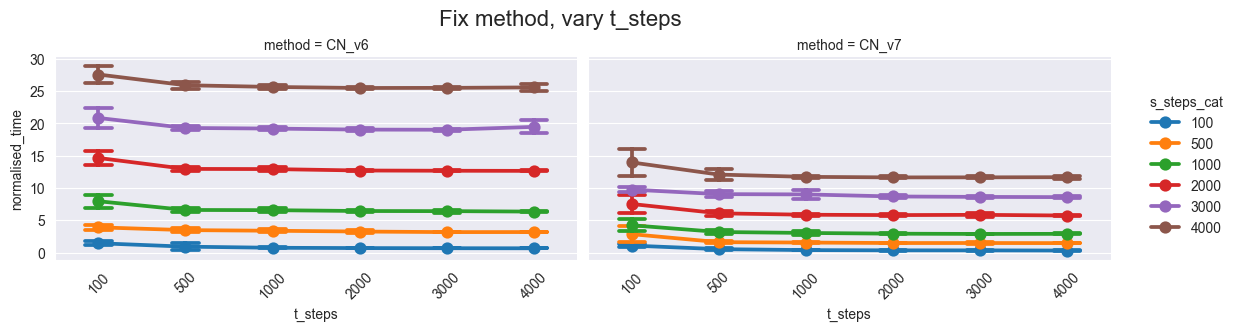

In [14]:
for c in ['s_steps', 't_steps']:
    df[f'{c}_cat'] = pd.Categorical(
        df[c].astype(str), ordered=True,
        categories=[str(v) for v in sorted(df[c].unique())])

def facet(x, hue, col, title, aspect=1.0, **kw):
    g = sns.catplot(data=df, x=x, y='normalised_time', hue=hue, col=col,
                    kind='point', errorbar='sd', capsize=.3,
                    height=3.2, aspect=aspect, sharey=True, **kw)
    g.tick_params(axis='x', rotation=45)
    g.figure.suptitle(title, fontsize=16)
    #g.set(yscale='log')
    g.figure.set_layout_engine('constrained')
    sns.move_legend(g, loc='center left', bbox_to_anchor=(1.02, 0.5))
    return g

facet('t_steps', 'method',      's_steps', 'Fix s steps, vary t steps')
facet('s_steps', 'method',      't_steps', 'Fix t steps, vary s steps', aspect=0.8)
facet('s_steps', 't_steps_cat', 'method',  'Fix method, vary s_steps',  aspect=1.6)
facet('t_steps', 's_steps_cat', 'method',  'Fix method, vary t_steps',  aspect=1.6)

In [15]:
call = EuropeanOption(K=K, T=T, contract_type="call")
p_true = call.price_closed_form(S0, r, sigma)
df['bias'] = df['result'] - p_true
df['absolute_bias'] = df['bias'].abs()

In [16]:
import numpy as np, pandas as pd, plotly.express as px

fns = [pde_crank_nicolson, pde_crank_nicolson_v2,  pde_crank_nicolson_v3,  pde_crank_nicolson_v4,  pde_crank_nicolson_v5,  pde_crank_nicolson_v6]

K = 100
T_STEPS = [500,501,1000, 1001]
WIN = 10

rows = []
for fn in fns:
    for t_steps in T_STEPS:
        V, grid = fn(K, S0, r, T, sigma, s_steps=9000, t_steps=t_steps)
        S = grid['S']
        i = np.searchsorted(S, K)
        sl = slice(max(i - WIN, 0), i + WIN)
        rows.append(pd.DataFrame({
            'S': S[sl],
            'result': V[sl],
            'method': fn.__name__,
            't_steps': str(t_steps),   # string -> discrete colors
        }))

check_oscillations = pd.concat(rows, ignore_index=True)

fig = px.line(check_oscillations, x='S', y='result', color='t_steps',
              facet_col='method', facet_col_wrap=3,
              markers=True, height=700,
              title=f'Crank–Nicolson near K={K}: t_steps 100 vs 101')
fig.update_yaxes(matches=None, showticklabels=True)   # each method on its own scale
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig.show()

check_oscillations['d2V'] = check_oscillations.groupby(['method', 't_steps'])['result'].transform(
    lambda s: s.diff().diff())

px.line(check_oscillations, x='S', y='d2V', color='t_steps',
        facet_col='method', facet_col_wrap=3, markers=True, height=700,
        title='Second difference of V — oscillation shows as sign flipping').show()